In [1]:
"""Smoke-test for the Rossmann store sales forecasting pipeline.

Generates a small synthetic dataset with a strong, easy-to-fit weekly pattern,
runs the full feature-engineering → nested CV pipeline, prints test-set metrics,
and plots real vs predicted sales for the last outer fold.

Usage: conda run -n rossmann python test_pipeline.py
"""

import os
import logging
import warnings

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import src.constants as C

from matplotlib import cm
from src.features import make_features, make_targets, attach_store_data
from src.preprocessing import drop_null_targets
from src.engine.cv import TimeSeriesCV
from src.engine.metrics import compute_metrics
from src.engine import utils, hypertuning

from src import synthetic

FORECAST_HORIZON = 5

os.makedirs(C.LOG_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO, 
                    filename=os.path.join(C.LOG_DIR, "test_pipeline.log"),
                    format="%(levelname)s  %(message)s")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

logger = logging.getLogger(__name__)



from pandas.tseries.offsets import DateOffset

def add_days_to_offset(offset: DateOffset, days_to_add: int) -> DateOffset:
    """
    Adds a specified number of days to a given DateOffset, returning a new DateOffset.
    Args:
        offset (DateOffset): The original DateOffset to which days will be added.
        days_to_add (int): The number of days to add to the original DateOffset.

    Returns:
        DateOffset: A new DateOffset that represents the original offset plus the added days.
    """
    kwds = offset.kwds.copy()
    kwds['days'] = kwds.get('days', 0) + days_to_add
    return DateOffset(**kwds)

c:\Users\m_kal\Downloads\rossmann_store_sales\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Synthetic Data

Strong deterministic weekly + trend signal so the model can overfit easily and produce low errors.

 DayOfWeek  Open  Promo StateHoliday  SchoolHoliday      Sales StoreType Assortment  CompetitionDistance CompetitionSinceDate Promo2SinceDate  Promo2
         2     1      0            0              0 467.320508         a          a                500.0           2012-03-01      2012-06-01       1
         2     1      0            0              0 617.320508         b          a               1200.0           2011-06-01             NaT       0
         2     1      1            0              0 867.320508         c          b                800.0           2013-01-01      2013-03-01       0
         3     1      0            0              0 467.470508         a          a                500.0           2012-03-01      2012-06-01       1
         3     1      0            0              0 617.470508         b          a               1200.0           2011-06-01             NaT       0


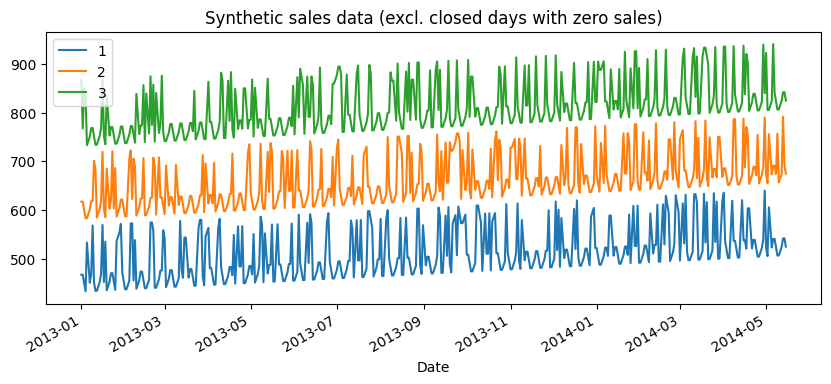

In [2]:
stores = synthetic.store_data()
train = synthetic.sales_data()
df  = attach_store_data(train, stores)
df.sort_values(['Date', 'Store'], inplace=True)  # Sort by date and store (ascending -> from earliest to latest) for lag features
df.set_index(["Date", "Store"], inplace=True)

cv_config = {
    "n_outer_splits":   C.N_OUTER_SPLITS,
    "n_inner_splits":   C.N_INNER_SPLITS,
    "forecast_horizon": FORECAST_HORIZON, #C.FORECAST_HORIZON,
    "inner_train_size": 80, #C.INNER_TRAIN_SIZE,
}

cv_config["outer_train_size"] = (cv_config["n_inner_splits"] + 1) * cv_config["forecast_horizon"] + cv_config["inner_train_size"]


study_config = {
    "storage_url":           C.STORAGE_URL,
    "n_trials":              C.NUM_TRIALS,
    "n_startup_trials":      C.NUM_STARTUP_TRIALS,
    "n_jobs":                C.NUM_JOBS,
    "seed":                  C.SEED,
    "xgb_constants":         C.XGB_CONSTANTS,
    "early_stopping_rounds": C.EARLY_STOPPING_ROUNDS,
    "num_boost_rounds":      C.NUM_BOOST_ROUNDS,
    "monitor_periods":       C.MONITOR_PERIODS,
    "hyperparameters":       C.HYPERPARAMETERS,
    "log_dir":               C.LOG_DIR,
}

print(df.head(5).to_string(index=False))

(
    df
    .loc[df['Sales'] > 0]
    .reset_index()
    .set_index("Date")
    .groupby("Store")["Sales"]
    .plot(figsize=(10, 4),
          title="Synthetic sales data (excl. closed days with zero sales)",
          legend=True)
)

plt.savefig(os.path.join(C.LOG_DIR, "training_set.png"))

In [3]:
# Make sure to add the forecast horizon to the lags, diffs, and rolling window offsets
# This ensures that the features are correctly aligned with the target variable, which is shifted by the forecast horizon.
# If we don't do this, the model will be trained on features that are not available at the time of prediction, leading \
# to data leakage and overly optimistic performance metrics.

lags = [add_days_to_offset(l, FORECAST_HORIZON) for l in C.LAGS]
diffs = [add_days_to_offset(d, FORECAST_HORIZON) for d in C.DIFFS]
rolling_windows = {}
for window, offsets in C.ROLL_WINDOWS.items():
    adjusted_offsets = [add_days_to_offset(offset, FORECAST_HORIZON) for offset in offsets]
    rolling_windows[window] = adjusted_offsets


Since the Rossmann test horizon is 6 weeks (42 days), any historical feature you use must look back at least 42 days. If you use a 42-day lag, you will always have real data available, even on the very last day of the prediction horizon.

Assume 1 store with 1 month of data. 30 rows. i need to predict 5 days into the future. How do X and y look like?

* [ Day 1 to Day 5 ]  -->  Used only to create lags for later days.
* [ Day 6 to Day 30 ] -->  Your actual Training Rows.

| Row | Date (X) | DayOfWeek (X) | Sales_Lag_5 (X) | ... | Actual Sales (y - Target) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 1 | Day 6 | Friday | Sales from Day 1 | ... | $5,000 |
| 2 | Day 7 | Saturday | Sales from Day 2 | ... | $6,200 |
| 3 | Day 8 | Sunday | Sales from Day 3 | ... | $0 (Closed) |
| ... | ... | ... | ... | ... | ... |
| 25 | Day 30 | Friday | Sales from Day 25 | ... | $5,400 |

In [4]:
df_processed = df.copy()
df_processed['Sales'] = utils.overwrite_closed_sales(df_processed['Sales'], mode='interpolate')
df_processed['Sales'] = df_processed['Sales'].groupby(level='Store').diff()

df_processed['Sales'].head(30)

Date        Store
2013-01-01  1               NaN
            2               NaN
            3               NaN
2013-01-02  1          0.150000
            2          0.150000
            3        -99.850000
2013-01-03  1        -17.170508
            2        -17.170508
            3         82.829492
2013-01-04  1        -17.170508
            2        -17.170508
            3        -17.170508
2013-01-05  1        100.150000
            2          0.150000
            3        -99.850000
2013-01-06  1        -41.189746
            2          8.810254
            3          8.810254
2013-01-07  1        -41.189746
            2          8.810254
            3          8.810254
2013-01-08  1         17.470508
            2         17.470508
            3         17.470508
2013-01-09  1        100.150000
            2          0.150000
            3          0.150000
2013-01-10  1       -117.170508
            2         82.829492
            3        -17.170508
Name: Sales, dtype: fl

In [5]:
make_targets(df_processed['Sales'], FORECAST_HORIZON).head(45)

5
Date       Store            
2013-01-01 1      -41.189746
           2        8.810254
           3        8.810254
2013-01-02 1      -41.189746
           2        8.810254
           3        8.810254
2013-01-03 1       17.470508
           2       17.470508
           3       17.470508
2013-01-04 1      100.150000
           2        0.150000
           3        0.150000
2013-01-05 1     -117.170508
           2       82.829492
           3      -17.170508
2013-01-06 1      -17.170508
           2      -17.170508
           3      -17.170508
2013-01-07 1        0.150000
           2      -99.850000
           3        0.150000
2013-01-08 1        8.810254
           2        8.810254
           3        8.810254
2013-01-09 1        8.810254
           2        8.810254
           3        8.810254
2013-01-10 1       17.470508
           2       17.470508
           3       17.470508
2013-01-11 1      100.150000
           2      100.150000
           3      100.150000
2013-01-12 1     -117.170508
           2     -117.170508
           3     -117.170508
2013-01-13 1       82.829492
           2      -17.170508
           3      -17.170508
2013-01-14 1      -99.850000
           2      100.150000
           3      100.150000
2013-01-15 1        8.810254
           2      -41.189746
           3      -41.189746

In [6]:

X = make_features(df_processed, lags, rolling_windows, diffs)
X[['lag_6_days', 'lag_7_days']].head(45)

lag_6_days  lag_7_days
Date       Store                        
2013-01-01 1             NaN         NaN
           2             NaN         NaN
           3             NaN         NaN
2013-01-02 1             NaN         NaN
           2             NaN         NaN
           3             NaN         NaN
2013-01-03 1             NaN         NaN
           2             NaN         NaN
           3             NaN         NaN
2013-01-04 1             NaN         NaN
           2             NaN         NaN
           3             NaN         NaN
2013-01-05 1             NaN         NaN
           2             NaN         NaN
           3             NaN         NaN
2013-01-06 1             NaN         NaN
           2             NaN         NaN
           3             NaN         NaN
2013-01-07 1             NaN         NaN
           2             NaN         NaN
           3             NaN         NaN
2013-01-08 1        0.150000         NaN
           2        0.150000         NaN
           3      -99.850000         NaN
2013-01-09 1      -17.170508    0.150000
           2      -17.170508    0.150000
           3       82.829492  -99.850000
2013-01-10 1      -17.170508  -17.170508
           2      -17.170508  -17.170508
           3      -17.170508   82.829492
2013-01-11 1      100.150000  -17.170508
           2        0.150000  -17.170508
           3      -99.850000  -17.170508
2013-01-12 1      -41.189746  100.150000
           2        8.810254    0.150000
           3        8.810254  -99.850000
2013-01-13 1      -41.189746  -41.189746
           2        8.810254    8.810254
           3        8.810254    8.810254
2013-01-14 1       17.470508  -41.189746
           2       17.470508    8.810254
           3       17.470508    8.810254
2013-01-15 1      100.150000   17.470508
           2        0.150000   17.470508
           3        0.150000   17.470508

In [ ]:

# Preprocessing steps:
# 1. Overwrite zero sales for Sundays (closed) with interpolated values based on adjacent open days, 
#    to allow feature creation for those days (e.g. lags, rolls, diffs, forecast horizon)
# 2. First-order differencing on the Sales column to make the series more stationary
# 3. Create features and targets for the whole dataset
# 4. Drop rows with null targets (i.e. those that don't have enough history
#    to create all requested lags, rolls, diffs, and/or forecast horizon)
df_processed = df.copy()
df_processed['Sales'] = utils.overwrite_closed_sales(df_processed['Sales'], mode='interpolate')
df_processed['Sales'] = df_processed['Sales'].groupby(level='Store').diff()
X = make_features(df_processed, C.LAGS, C.ROLL_WINDOWS, C.DIFFS)
y = make_targets(df_processed['Sales'], C.FORECAST_HORIZON)
X, y = drop_null_targets(X, y)

cv = TimeSeriesCV(n_splits=cv_config["n_outer_splits"],
                  horizon=cv_config["forecast_horizon"],
                  train_size=cv_config["outer_train_size"])

for fold, (train_ix, test_ix) in enumerate(cv.split(X, y), start=1):
    logger.info(f"Outer fold {fold}/{cv_config['n_outer_splits']} starting...")

    study_name = f"fold_{fold}"
    X_train, y_train = X.iloc[train_ix], y.iloc[train_ix]
    X_test, y_test = X.iloc[test_ix], y.iloc[test_ix]
    
    # Run Optuna hyperparameter tuning with nested CV in the inner loop
    logger.info(f"Running hyperparameter tuning ({study_config['n_trials']} trials)...")
    #hypertuning.optimize(study_name, X_train, y_train, {**cv_config, **study_config})

    # Retrain final model on the entire outer fold training set with the best hyperparameters
    logger.info(f"Retraining model with the best hyperparameters...")
    study = optuna.load_study(study_name=study_name, storage=study_config["storage_url"])
    booster = hypertuning.refit(X_train, y_train, study.best_trial, study_config)
    
    logger.info(f"Evaluating final model on outer fold {fold} test set...")
    preds = utils.predict(booster, X_test)

    # Inverse first-order differencing to get predictions back on the original scale
    origin_index = preds.index.droplevel('Forecast Date')
    anchors = (utils.overwrite_closed_sales(df['Sales'], mode='interpolate')
               .loc[origin_index]
               .set_axis(preds.index))
    preds = anchors + preds.groupby(level=['Date', 'Store']).cumsum()
    
    # Log metrics and artifacts
    actuals = utils.retrieve_sales(df['Sales'], preds.index)
    metrics = compute_metrics(actuals.values, preds.values)
    logger.info(f"Test set metrics for fold {fold}: {metrics}")
    
    booster_file = os.path.join(study_config["log_dir"], study_name, "model.ubj")
    preds_file = os.path.join(study_config["log_dir"], study_name, "predictions.csv")
    booster.save_model(booster_file)
    preds.to_csv(preds_file)

    break


In [25]:
booster_file_1 = f"C:\\Users\\m_kal\\Downloads\\rossmann_store_sales\\artifacts\\fold_1\\trial_{study.best_trial.number:04d}\\fold_3.ubj"
booster_file_2 = os.path.join(study_config["log_dir"], study_name, "model.ubj")
bfiles = [booster_file_2, booster_file_1]

for booster_file in bfiles:

    booster = xgb.Booster()
    booster.load_model(booster_file)
    preds = utils.predict(booster, X_test)

    # ------------------------------------------------------------------------------
    # Inverse first-order differencing to get predictions back on the original scale
    origin_index = preds.index.droplevel('Forecast Date')
    anchors = utils.overwrite_closed_sales(df['Sales'], mode='interpolate').loc[origin_index].set_axis(preds.index)
    preds = anchors + preds.groupby(level=['Date', 'Store']).cumsum()
    # ------------------------------------------------------------------------------

    actuals_idx = preds.index.droplevel("Date").swaplevel()  # (Forecast Date, Store)
    true_vals = df.loc[actuals_idx, "Sales"]

    m = compute_metrics(true_vals.values, preds.values)
    print(f"Metrics for {booster_file}: {m}")

Metrics for ./artifacts\fold_1\model.ubj: {'MAE': 48.882, 'RMSE': 63.601, 'MAPE': 7.094, 'RMSPE': 9.136}
Metrics for C:\Users\m_kal\Downloads\rossmann_store_sales\artifacts\fold_1\trial_0049\fold_3.ubj: {'MAE': 53.308, 'RMSE': 68.71, 'MAPE': 7.753, 'RMSPE': 9.88}


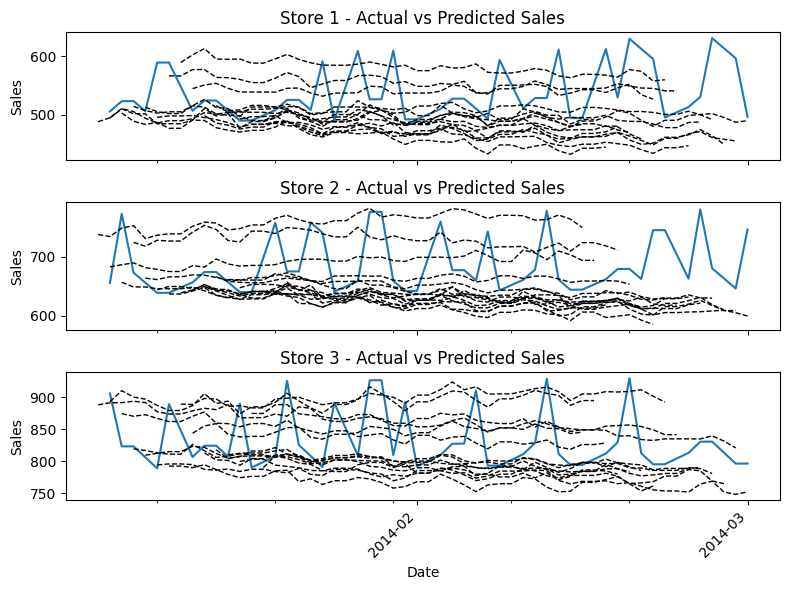

In [28]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

actual = df['Sales']

def plot_actual_vs_predicted(actual, preds):
        
    stores = actual.index.get_level_values("Store").unique()
    fig, ax = plt.subplots(figsize=(8, 6), nrows=len(stores), sharex=True, sharey=False)

    for i, store in enumerate(stores):

        actual_store_sales = (utils.retrieve_sales(actual, preds.index)
                            .loc[(slice(None), store)]
                            .sort_index())
        
        predicted_store_sales = (preds
                                .loc[(slice(None), store, slice(None))]
                                .reset_index())

        # exclude closed days with zero sales and zero predictions
        actual_store_sales = actual_store_sales[actual_store_sales > 0]
        predicted_store_sales = predicted_store_sales[predicted_store_sales[0] > 0]

        actual_store_sales.plot(label=f"Store {store}", ax=ax[i])
        (predicted_store_sales
        .groupby("Date")
        .plot(x="Forecast Date", y=0, ax=ax[i], color='k', linestyle='--', linewidth=1))

        ax[i].get_legend().remove()
        ax[i].set_title(f"Store {store} - Actual vs Predicted Sales")
        ax[i].set_ylabel("Sales")
        
    # Rotate x labels and set date format
    ax[-1].xaxis.set_major_locator(mdates.MonthLocator())
    ax[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    ax[-1].set_xlabel("Date")
    plt.tight_layout()

    return 

plot_actual_vs_predicted(actual, preds)